# 01 - Exploratory Data Analysis & Data Foundation
**SPE Africa Geothermal Datathon 2026 - Challenge 1 - Team Vent Squad**

This notebook establishes the clean, unit-consistent, depth-referenced data
foundation that every later result is built on, for the four Utrecht-region wells
(BLT-01, EVD-01, JUT-01, PKP-01) targeting the **Rotliegend / Slochteren Formation**
sandstone. It runs top-to-bottom from a fresh clone; all logic lives in `src/` and is
unit-tested, so each figure and table below is reproducible rather than asserted.

**What this notebook establishes**
1. Curve inventory and coverage per well (BLT-01 is the anchor).
2. Unit harmonisation (JUT-01 in feet) and null/spike cleaning.
3. Minimum-curvature **MD->TVD**, validated against the survey TVD column.
4. Recovery of the flagged `target_lithologies.csv` depths.
5. First-pass petrophysics (V_shale, density porosity) + Rotliegend summary.

In [1]:
import logging, warnings
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING, format="%(levelname)s %(message)s")

import sys
from pathlib import Path
ROOT = Path.cwd()
if (ROOT / "src").exists():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / "src").exists():
    sys.path.insert(0, str(ROOT.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.paths import FIGURES
from src.wells_io import WELLS, STANDARD_CURVES, load_all, coverage_table
from src.petrophysics import add_petrophysics, rotliegend_summary
from src.lithostrat import rotliegend_pick
from src.mdtvd import load_survey, md_to_tvd, validate_survey
from src.targets import build_target_tvd
from src.constants import WELLS as META

FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
WELLS

['BLT-01', 'EVD-01', 'JUT-01', 'PKP-01']

## 1. Load, clean, unit-harmonise, TVD-reference

`load_all()` reads every LAS, masks the `-999.25` null, applies physical-range
gates (JUT-01 carries spike values in the millions on DT/RHOB), converts JUT-01
feet->metres once, sorts the bottom-up-logged EVD-01/PKP-01 ascending, and
attaches a per-sample TVD. We then add `vsh`/`phi_d`.

In [2]:
logs = add_petrophysics(load_all())
cov = coverage_table(logs)
cov

,well,n_samples,md_min_m,md_max_m,tvd_max_m,GR,DTC,DTS,RHOB,NPHI,DRHO,PE,RD,RM,RS,CALI
0,BLT-01,27875,0.0000,2123.9988,2052.343380,27248,24295,19881,19975,27393,19975,19981,25336,25336,25336,19946
1,EVD-01,21569,40.1002,2196.9004,2180.496826,21398,21219,0,3220,0,3177,0,0,0,0,0
2,JUT-01,22427,2.1336,3419.8560,3335.237163,22410,20275,0,15747,0,0,0,0,0,0,0
3,PKP-01,27508,0.2002,2750.9004,2404.322325,26639,21270,0,21171,9108,21171,0,0,0,0,0


**Coverage read-out.** BLT-01 has the full petrophysical suite and is the
modelling anchor. The others are sonic+GR-led with sparse density/neutron - the
natural place for the bonus ML log-prediction track.

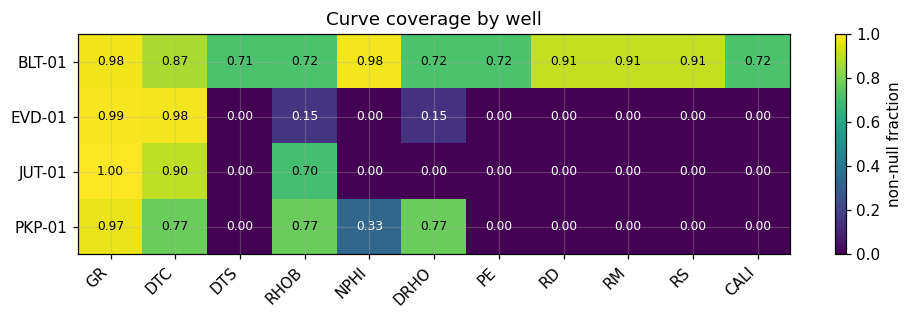

In [3]:
frac = cov.set_index("well")[STANDARD_CURVES].div(cov.set_index("well")["n_samples"], axis=0)
fig, ax = plt.subplots(figsize=(9, 3))
im = ax.imshow(frac.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(STANDARD_CURVES))); ax.set_xticklabels(STANDARD_CURVES, rotation=45, ha="right")
ax.set_yticks(range(len(frac))); ax.set_yticklabels(frac.index)
for (i, j), v in np.ndenumerate(frac.values):
    ax.text(j, i, f"{v:.2f}", ha="center", va="center",
            color="white" if v < 0.6 else "black", fontsize=8)
fig.colorbar(im, ax=ax, label="non-null fraction"); ax.set_title("Curve coverage by well")
fig.tight_layout(); fig.savefig(FIGURES / "coverage.png"); plt.show()

## 2. Raw curves per well

Cleaned curves vs measured depth - note the uneven suites and the character
change entering the Slochteren sand at the base of each well.

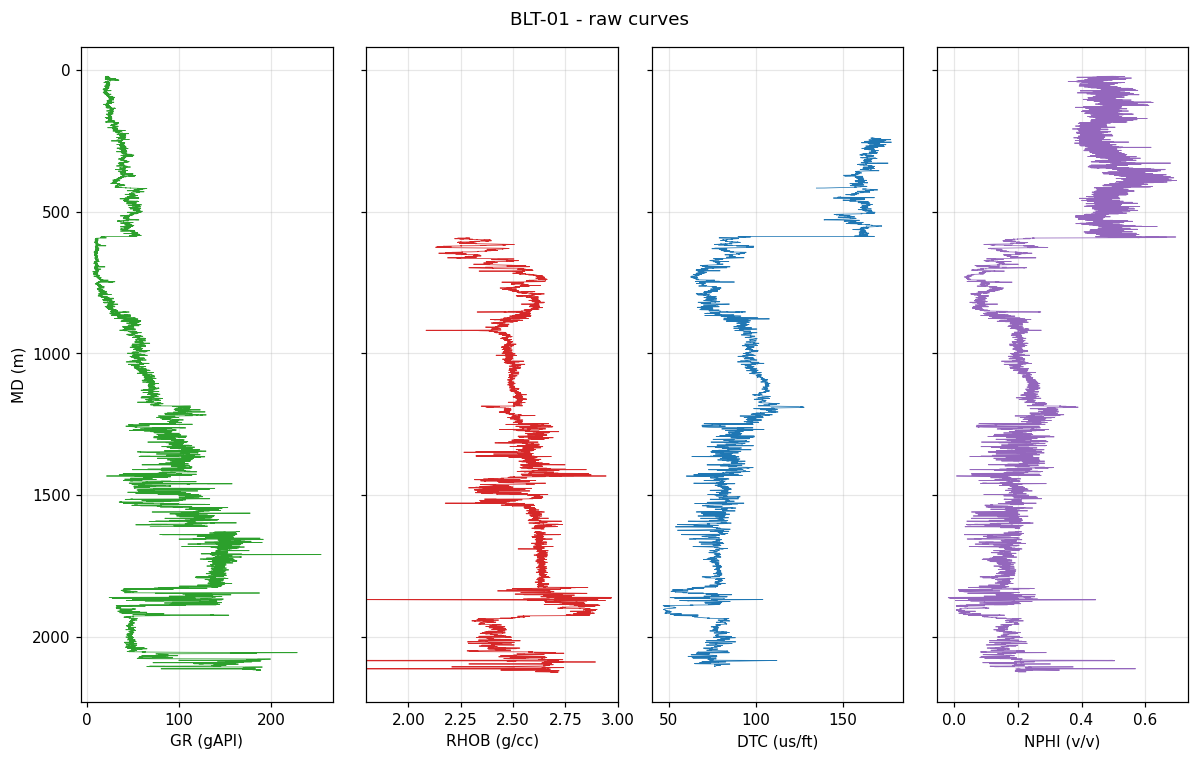

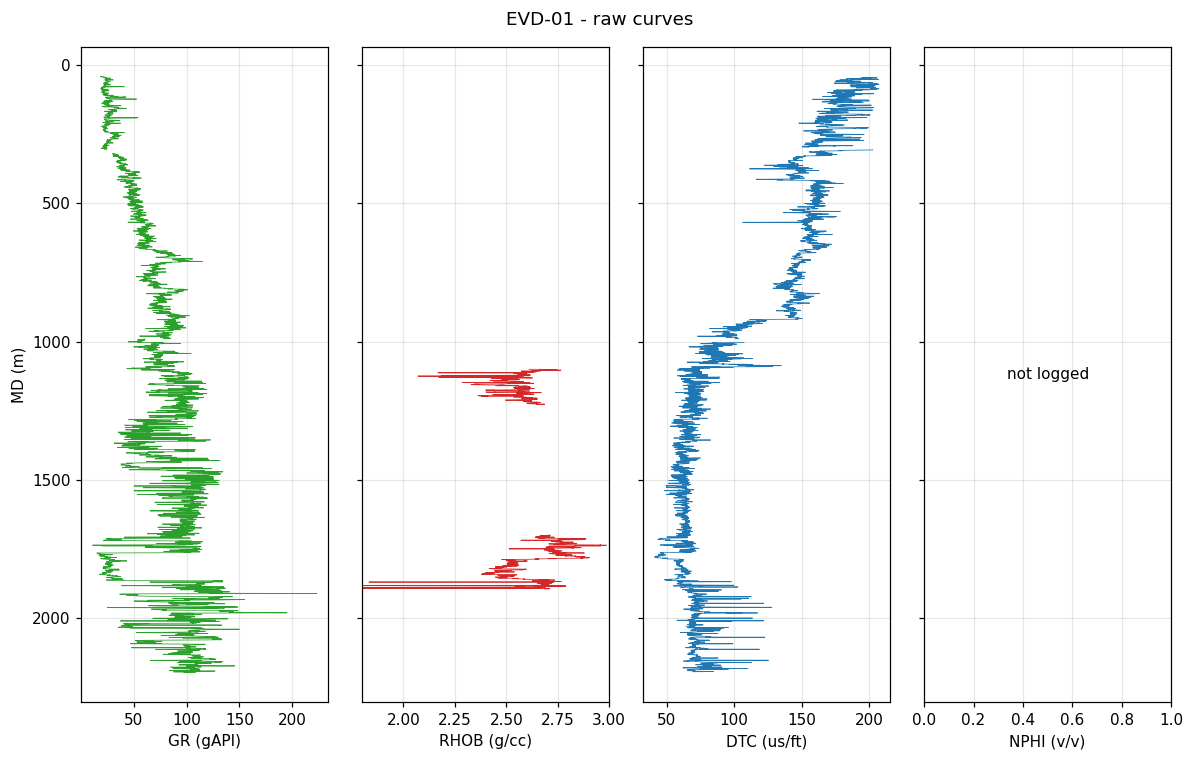

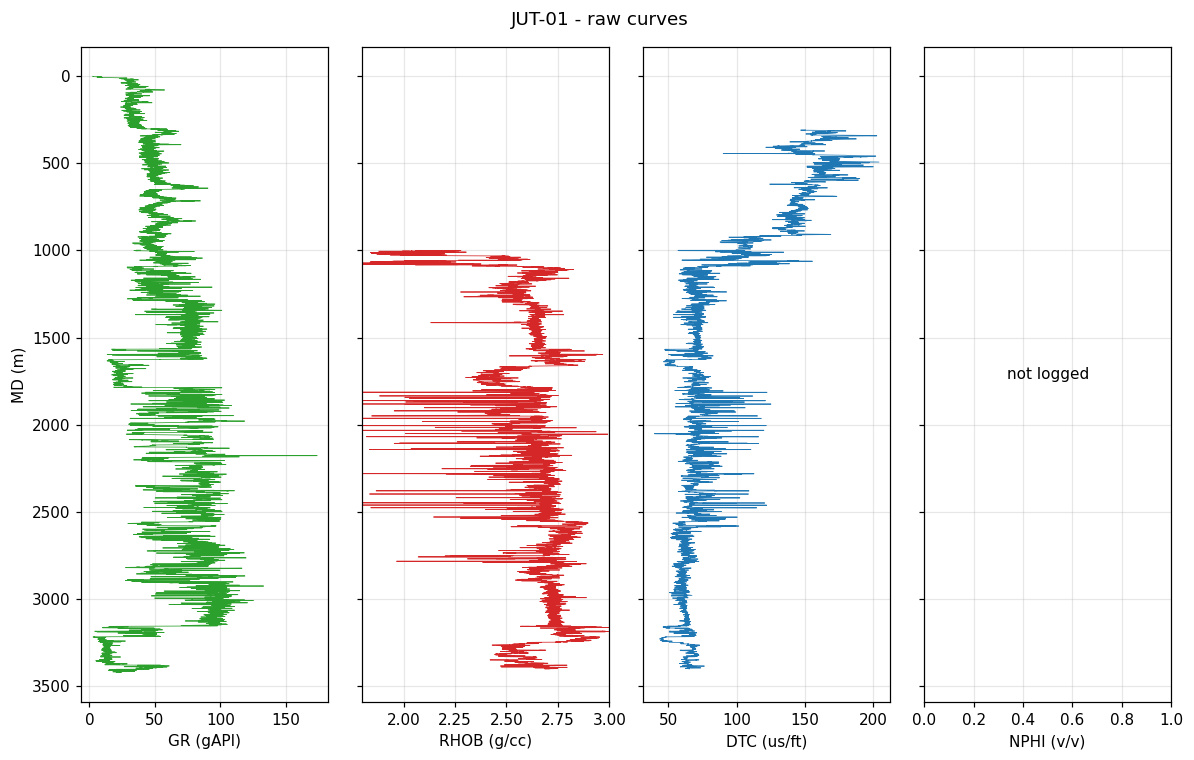

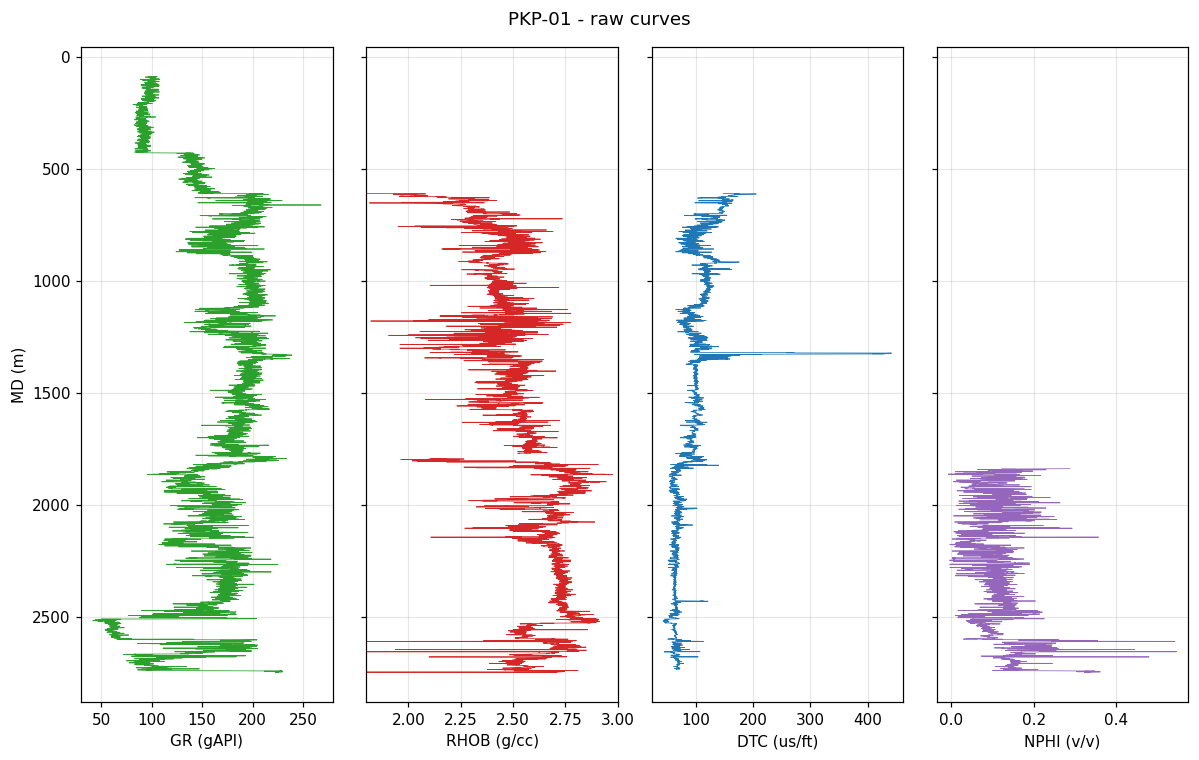

In [4]:
def plot_raw_curves(well):
    g = logs[logs.well == well]
    tracks = [("GR", "GR (gAPI)", "tab:green", None),
              ("RHOB", "RHOB (g/cc)", "tab:red", (1.8, 3.0)),
              ("DTC", "DTC (us/ft)", "tab:blue", None),
              ("NPHI", "NPHI (v/v)", "tab:purple", None)]
    fig, axes = plt.subplots(1, len(tracks), figsize=(11, 7), sharey=True)
    for ax, (c, lab, col, xlim) in zip(axes, tracks):
        if g[c].notna().any():
            ax.plot(g[c], g.md_m, col, lw=0.5)
            if xlim: ax.set_xlim(*xlim)
        else:
            ax.text(0.5, 0.5, "not logged", ha="center", va="center", transform=ax.transAxes)
        ax.set_xlabel(lab)
    axes[0].set_ylabel("MD (m)"); axes[0].invert_yaxis()
    fig.suptitle(f"{well} - raw curves"); fig.tight_layout()
    fig.savefig(FIGURES / f"raw_curves_{well}.png"); plt.show()

for w in WELLS:
    plot_raw_curves(w)

## 3. MD->TVD validation

Recomputed minimum-curvature station TVD vs the workbook TVD column - agreement
is sub-centimetre on all four wells. PKP-01 is the most deviated (~37 deg).

In [5]:
val = pd.DataFrame([validate_survey(w) for w in WELLS])
val[["well","n_stations","max_abs_resid_m","rms_resid_m","max_inclination_deg","md_max_m","tvd_max_m"]].round(4)

WARNING EVD-01: sparse survey (21 stations); MD->TVD interpolation is coarse, falling back to effectively piecewise-linear.


,well,n_stations,max_abs_resid_m,rms_resid_m,max_inclination_deg,md_max_m,tvd_max_m
0,BLT-01,102,0.0052,0.0029,19.67,2123.0,2051.3986
1,EVD-01,21,0.0043,0.0024,16.25,2197.5,2181.0726
2,JUT-01,33,0.0095,0.0048,25.50,3409.0,3324.6184
3,PKP-01,110,0.0053,0.0030,37.28,2751.0,2404.4127


WARNING JUT-01: 2 Slochteren picks; using deepest (top_md=3240.0 m).


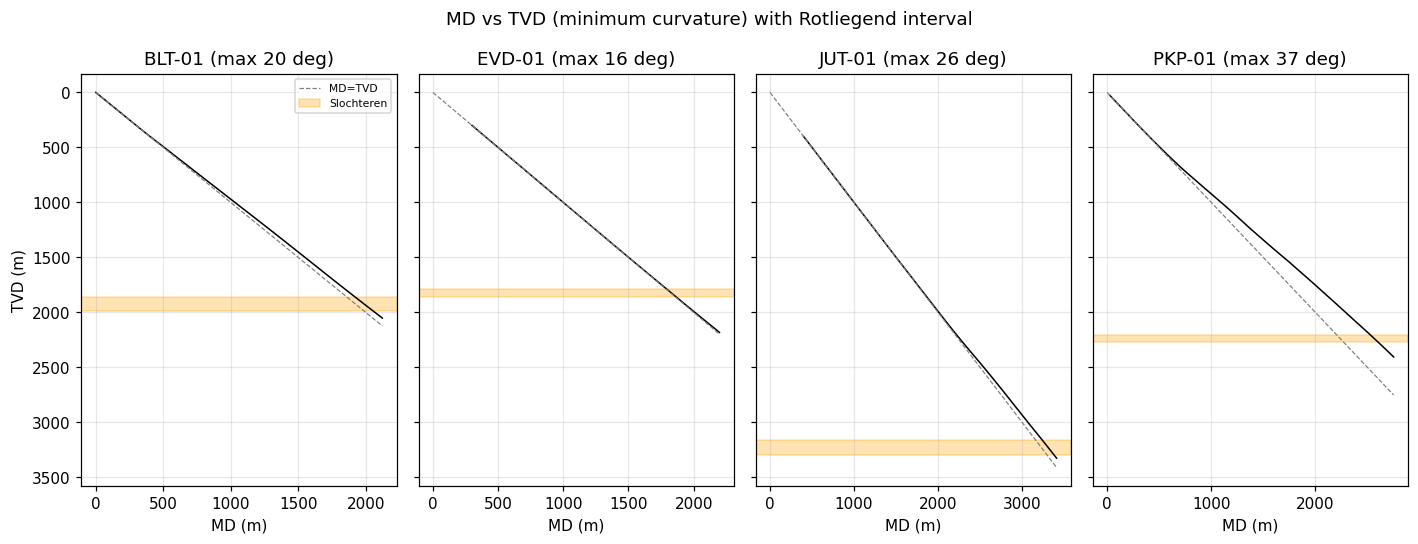

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(13, 5), sharey=True)
for ax, w in zip(axes, WELLS):
    s = load_survey(w)
    ax.plot(s.md, md_to_tvd(w, s.md), "k-", lw=1)
    ax.plot([0, s.md.max()], [0, s.md.max()], "--", color="grey", lw=0.8, label="MD=TVD")
    pick = rotliegend_pick(w)
    ax.axhspan(pick["top_tvd"], pick["base_tvd"], color="orange", alpha=0.3, label="Slochteren")
    ax.set_title(f"{w} (max {s.incl_deg.max():.0f} deg)"); ax.set_xlabel("MD (m)")
axes[0].set_ylabel("TVD (m)"); axes[0].invert_yaxis(); axes[0].legend(fontsize=7)
fig.suptitle("MD vs TVD (minimum curvature) with Rotliegend interval")
fig.tight_layout(); fig.savefig(FIGURES / "md_vs_tvd.png"); plt.show()

## 4. Recovering `target_lithologies.csv`

The shipped file flags every row "AH depth - deviated well needs TVD conversion"
and leaves `depth_tvd_m` empty. `formation_top/base` are actually along-hole MD
(feet for JUT-01), and each row is an exact LAS sample identifiable by its GR -
top->base for BLT-01/JUT-01, reversed for the bottom-up-logged EVD-01/PKP-01.

In [7]:
tgt = build_target_tvd()
chk = tgt.groupby("well_id").agg(
    n=("md_m","size"), tvd_min=("depth_tvd_m","min"), tvd_max=("depth_tvd_m","max"),
    top_tvd=("formation_top_tvd","first"), base_tvd=("formation_base_tvd","first")).round(1)
chk["lithostrat_top_tvd"] = [round(rotliegend_pick(w)["top_tvd"],1) for w in chk.index]
chk["top_diff_m"] = (chk.top_tvd - chk.lithostrat_top_tvd).abs().round(1)
chk["review"] = np.where(chk.top_diff_m > 10, "REVIEW", "ok")
chk

WARNING JUT-01: 2 Slochteren picks; using deepest (top_md=3240.0 m).


,n,tvd_min,tvd_max,top_tvd,base_tvd,lithostrat_top_tvd,top_diff_m,review
well_id,,,,,,,,
BLT-01,1689,1862.5,1984.8,1862.5,1984.9,1862.5,0.0,ok
EVD-01,780,1782.7,1859.5,1782.7,1859.6,1782.7,0.0,ok
JUT-01,256,505.8,544.7,505.8,544.7,3161.4,2655.6,REVIEW
PKP-01,730,2207.2,2271.6,2207.2,2271.6,2207.2,0.0,ok


**Cross-check.** Target tops match the lithostrat Slochteren tops to 0.0 m
for BLT-01/EVD-01/PKP-01. **JUT-01 is flagged**: its target GR traces uniquely to
~506 m (1659.5 *ft* - a feet/metre error in the source file), whereas its true
Slochteren sits at ~3161 m TVD below the Zechstein. JUT-01 target rows are
excluded from reservoir aggregation pending manual review.

## 5. Petrophysics - BLT-01 anchor

Larionov-older V_shale and density porosity over BLT-01, Slochteren reservoir
shaded, net-reservoir flag where V_sh < 0.40 and phi > 0.08.

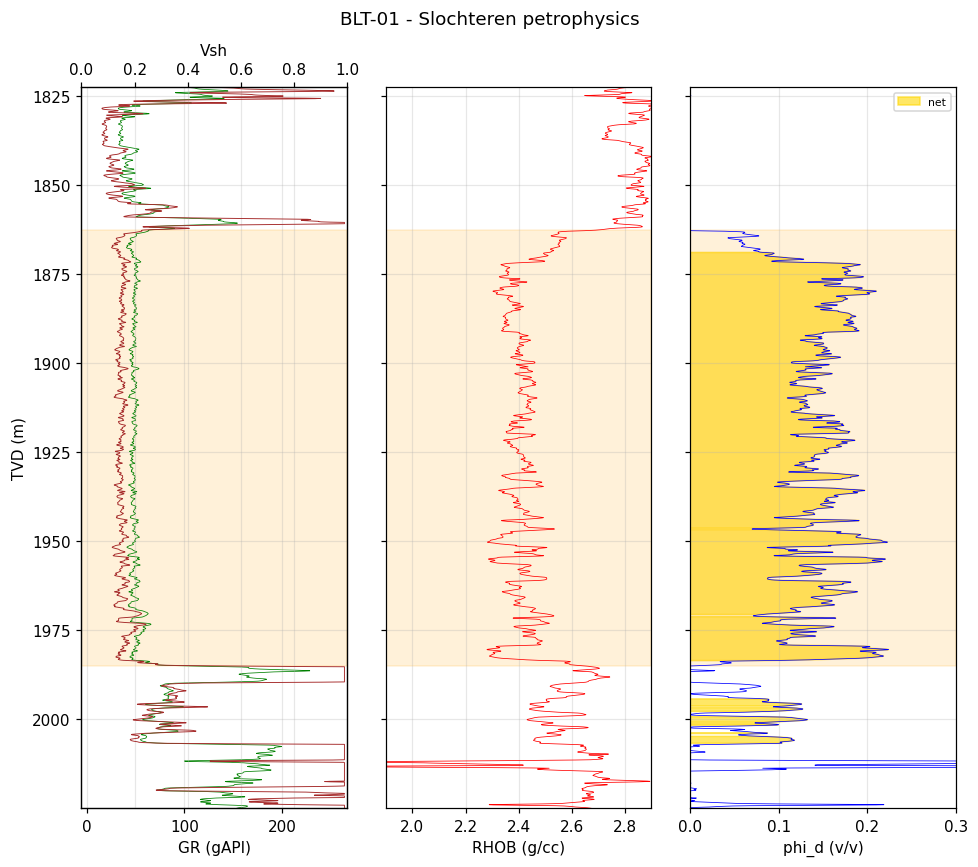

In [8]:
def plot_petro(well):
    g = logs[logs.well == well].sort_values("tvd_m")
    pick = rotliegend_pick(well)
    net = (g.vsh < 0.40) & (g.phi_d > 0.08)
    fig, axes = plt.subplots(1, 3, figsize=(9, 8), sharey=True)
    axes[0].plot(g.GR, g.tvd_m, "g", lw=0.5); axes[0].set_xlabel("GR (gAPI)")
    ax0b = axes[0].twiny(); ax0b.plot(g.vsh, g.tvd_m, "brown", lw=0.6); ax0b.set_xlabel("Vsh"); ax0b.set_xlim(0,1)
    axes[1].plot(g.RHOB, g.tvd_m, "r", lw=0.5); axes[1].set_xlabel("RHOB (g/cc)"); axes[1].set_xlim(1.9,2.9)
    axes[2].plot(g.phi_d, g.tvd_m, "b", lw=0.5); axes[2].set_xlabel("phi_d (v/v)"); axes[2].set_xlim(0,0.3)
    axes[2].fill_betweenx(g.tvd_m, 0, g.phi_d.where(net), color="gold", alpha=0.6, label="net")
    for ax in axes:
        ax.axhspan(pick["top_tvd"], pick["base_tvd"], color="orange", alpha=0.15)
    axes[0].set_ylabel("TVD (m)"); axes[0].set_ylim(pick["base_tvd"]+40, pick["top_tvd"]-40)
    axes[2].legend(fontsize=7); fig.suptitle(f"{well} - Slochteren petrophysics")
    fig.tight_layout(); fig.savefig(FIGURES / f"petro_{well}.png"); plt.show()

plot_petro("BLT-01")

## 6. Rotliegend net-reservoir summary (all wells)

In [9]:
summary = pd.DataFrame([rotliegend_summary(logs, rotliegend_pick(w)) for w in WELLS])
summary["thermoGIS_top_m"] = [META[w].top_rotliegend_m for w in WELLS]
summary["thermoGIS_phi"]   = [META[w].porosity_pct_p50/100 for w in WELLS]
summary

WARNING JUT-01: 2 Slochteren picks; using deepest (top_md=3240.0 m).


,well,top_tvd_m,base_tvd_m,gross_tvd_m,n_samples,n_with_phi,net_tvd_m,ntg,phi_mean_net,phi_mean_all,vsh_mean,tvd_step_m,thermoGIS_top_m,thermoGIS_phi
0,BLT-01,1862.5,1984.9,122.4,1689,1689,113.8,0.930,0.1501,0.1436,0.154,0.0724,1837,0.17
1,EVD-01,1782.7,1859.6,76.8,780,780,42.1,0.548,0.1089,0.0837,0.033,0.0985,1723,0.09
2,JUT-01,3161.4,3294.5,133.0,906,906,42.3,0.318,0.0986,0.0563,0.003,0.1479,1776,0.11
3,PKP-01,2207.2,2271.6,64.4,730,730,6.6,0.103,0.0906,0.0537,0.004,0.0883,2255,0.09


### What the data foundation tells us

* **BLT-01 is the development anchor** - gross ~122 m of Slochteren, **net-to-gross
  0.93**, net porosity ~15% (ThermoGIS 17%): the thickest, cleanest, most porous of
  the four, and the well every downstream calculation is anchored on.
* **EVD-01** - NTG ~0.55, phi ~11%: moderate.
* **PKP-01** - **NTG 0.10**, very tight (consistent with its low ThermoGIS
  permeability of ~1 mD).
* **JUT-01** - structurally complex (a reverse fault repeats the Slochteren section)
  with a deliberately corrupted target interval; we isolate and flag it rather than
  let it contaminate the aggregate.

A note on net-to-gross we make openly: our log-based NTG matches ThermoGIS at the
anchor well (0.93 vs 0.98) but is deliberately *stricter* at the three weaker wells,
where ThermoGIS publishes a regional play-average of 0.95-0.99. We trust the
well-specific logs there, which makes our characterisation the more conservative; and
because the resource estimate (notebook 03) is anchored on ThermoGIS's own published
flow rate, this disagreement sharpens the picture without changing the headline
deliverability. With a trustworthy data foundation in hand, notebook 03 turns these
rock properties into a probabilistic resource estimate and the doublet design.